In [ ]:
import logging, sys
from graph_utils import NeatFormatter

handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(NeatFormatter())
logging.root.handlers = []
logging.root.addHandler(handler)
logging.root.setLevel(logging.INFO)

from populate import populate_all
from enrich_full_manual import enrich_all
from reasoning import check_consistency
from graph_embedding import (
    load_object_property_triples,
    train_embedding_model,
    save_embedding_model,
    load_embedding_model,
    visualize_embeddings,
    build_entity_type_map,
    build_subclass_ancestors,
    filter_predictions_by_class,
    TOP_K_PREDICTIONS,
)
from config import ONT
from graph_utils import local_name, reset_data_file, save_graph
from pykeen.predict import predict_target
from visualize import main as run_visualize


/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Reset data.owl & Populate From DbPedia

In [2]:
graph = reset_data_file()
populate_all(graph)


▸ Province
  · East_Nusa_Tenggara
  · West_Nusa_Tenggara
  · Bali

▸ Island
  · Nusa_Penida  (locatedIn: Bali)
  · Nusa_Lembongan  (locatedIn: Bali)
  · Serangan_Island  (locatedIn: Bali)
  · Menjangan_Island  (locatedIn: Bali)
  · Nusa_Ceningan  (locatedIn: Bali)
  ↳ Bali: 5 islands
  · Moyo_Island  (locatedIn: West_Nusa_Tenggara)
  · Lombok  (locatedIn: West_Nusa_Tenggara)
  · Satonda_Island  (locatedIn: West_Nusa_Tenggara)
  · Bungin_Island  (locatedIn: West_Nusa_Tenggara)
  ↳ NTB: 4 islands
  · Flores  (locatedIn: East_Nusa_Tenggara)
  · Komodo_island  (locatedIn: East_Nusa_Tenggara)
  · Rote_Island  (locatedIn: East_Nusa_Tenggara)
  · Pamana_Island  (locatedIn: East_Nusa_Tenggara)
  · Besar_Island_Flores  (locatedIn: East_Nusa_Tenggara)
  · Dambila  (locatedIn: East_Nusa_Tenggara)
  · Pantar  (locatedIn: East_Nusa_Tenggara)
  · Palu_e  (locatedIn: East_Nusa_Tenggara)
  · Ndao_Island  (locatedIn: East_Nusa_Tenggara)
  · Dana_Island_Sabu_Raijua  (locatedIn: East_Nusa_Tenggara)
  · 

# Enrich, Save, Reason

In [3]:
import os, sys

enrich_all(graph)
save_graph(graph)

# Suppress owlready2 stdout (java command line, HermiT timing, cyclic-type warnings)
with open(os.devnull, "w") as _devnull:
    _stdout, sys.stdout = sys.stdout, _devnull
    result = check_consistency()
    sys.stdout = _stdout

print("Ontology is", "CONSISTENT ✓" if result else "INCONSISTENT ✗")



▸ Backbone

▸ Island -> Province

▸ Activity Individuals

▸ Extra Cities

▸ Curated Attractions

▸ Transportation

▸ Fallback Activities

▸ Capital Hubs

▸ Data Properties

▸ Extra Links
Pre-loaded: alergy_ingredients_dishes.ttl
Pre-loaded: establishments (synthesised from curated_data)
Loaded schema=schema.owl data=data.owl


* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/owlready2/hermit:/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////var/folders/1j/z8zbdmfs73j3wgb3vtt985140000gn/T/tmp_2i9ky34 -Y


Ontology is CONSISTENT
Individuals per populated class:
  Province              ( 3) Bali, West_Nusa_Tenggara, East_Nusa_Tenggara
  Island                (30) Besar_Island__Flores, Flores, Lombok, Sumba, Sumbawa, Serangan_Island …
  City                  (50) Central_Lombok_Regency, Central_Sumba_Regency, East_Flores_Regency, East_Lombok_Regency, East_Sumba_Regency, Kintamani__Bali …
  Beach                 (23) Lovina_Beach, Nembrala, Nihiwatu_Beach, Pink_Beach, Koka_Beach, Lasiana_Beach …
  Park                  (29) Komodo_National_Park, Taman_Ujung_Water_Palace, Tambora_National_Park, Sacred_Monkey_Forest_Sanctuary, Bali_Botanic_Garden, Seventeen_Islands_Marine_Park …
  Volcano               ( 4) Bratan_volcano, Mount_Agung, Mount_Batur, Mount_Tambora
  Museum                (11) Le_Mayeur_Museum, Semarajaya_Museum, Neka_Art_Museum, Bali_Museum, Museum_Pasifika, Museum_Rudana …
  Temple                (14) Pura_Segara_Rupek, Tanah_Lot, Uluwatu_Temple, Besakih, Pura_Tirta_Empul, Goa

* Owlready2 * HermiT took 1.6949970722198486 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


# Graph Embedding

In [4]:
# Train embedding model

%matplotlib inline

emb_graph, base_triples = load_object_property_triples()
training_result, triples_factory = train_embedding_model(base_triples, 400)
save_embedding_model(training_result, triples_factory)
entity_type_map = build_entity_type_map(emb_graph)
ancestors_map = build_subclass_ancestors(emb_graph)

No cuda devices were available. The model runs on CPU
Using device: None
Inferred unique=False for Embedding()
Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 400/400 [00:53<00:00,  7.54epoch/s, loss=0.222, prev_loss=0.222]

When evaluating the test dataset, validation triples are added to the set of known positive triples which are filtered out when performing filtered evaluation following the approach described by (Bordes et al., 2013).
Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.



Evaluating on cpu:   0%|          | 0.00/1.78k [00:00<?, ?triple/s]

Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).


Evaluating on cpu: 100%|██████████| 1.78k/1.78k [00:00<00:00, 13.1ktriple/s]

Evaluation took 0.15s seconds


Stored TriplesFactory(num_entities=581, num_relations=21, create_inverse_triples=False, num_triples=1782) to file:///Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/embedding_model/triples
Saved embedding model -> embedding_model/


# (Optional) Load embedding from saved model

In [ ]:
# Load embedding from saved model

try:
    training_result = training_result.model
except NameError:
    training_result, triples_factory = load_embedding_model()
    emb_graph, _ = load_object_property_triples()
    entity_type_map = build_entity_type_map(emb_graph)
    ancestors_map = build_subclass_ancestors(emb_graph)
else:
    training_result = training_result.model

Loading from file:///Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/embedding_model/triples
No random seed is specified. This may lead to non-reproducible results.
Inferred unique=False for Embedding()
Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
Loaded embedding model ← embedding_model/


Saved cluster plot -> ./graph_vis/embedding_clusters.png


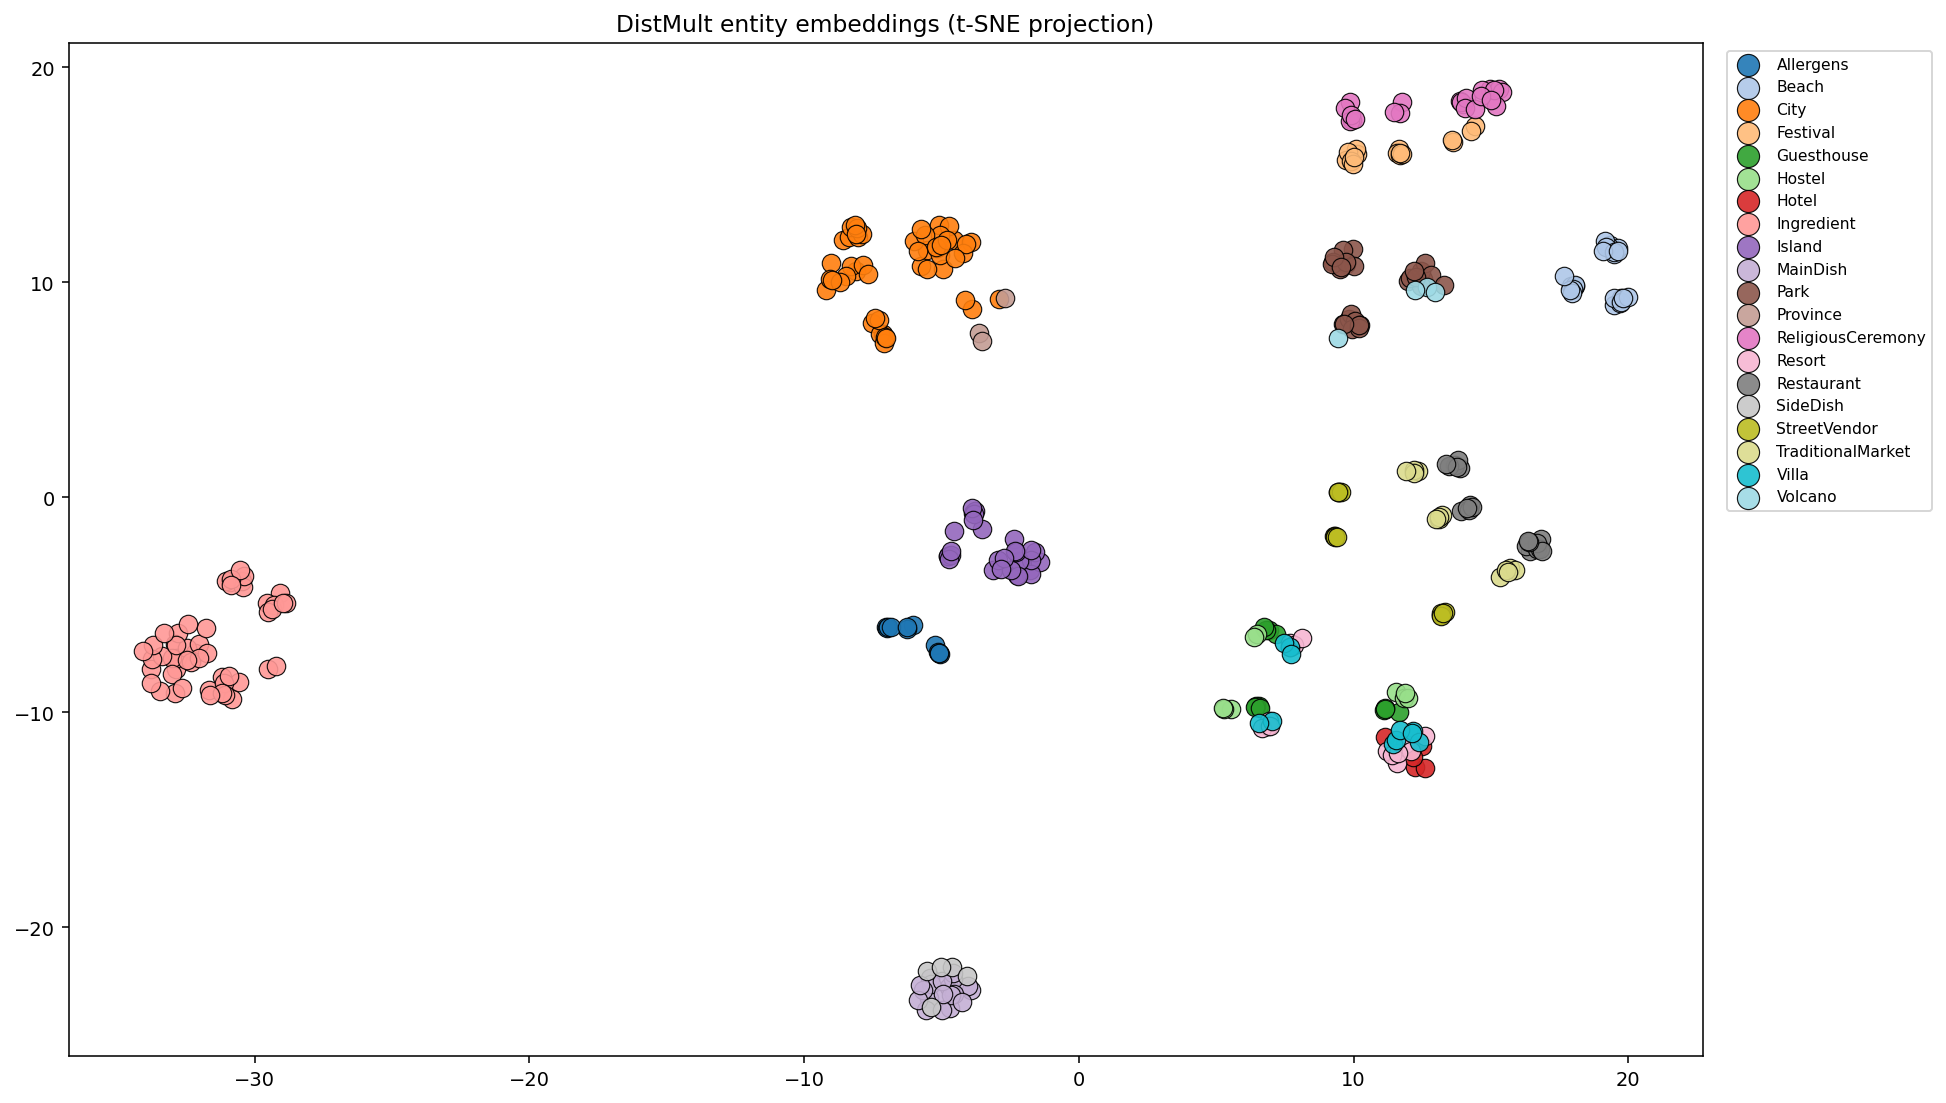

In [5]:
# Visualize embedding
from IPython.display import Image, display

visualize_embeddings(training_result.model, triples_factory, emb_graph)
display(Image(filename="graph_vis/embedding_clusters.png"))

# Link Prediction

Change `head`, `relation`, and `expected_class` below, then re-run the cell.

In [6]:
# Define as many queries as you like, then rerun this cell
# (head, relation, expected_class)
queries = [
    ("Pink_Beach",            "locatedIn",              "Park"),
    ("Satonda_Island",        "hasFood",                "TypicalFood"),
    ("Komodo_National_Park",  "hasActivity",            "Activities"),
    ("Lovina_Beach",          "hasActivity",            "Activities"),
    ("Pura_Taman_Ayun",       "hasActivity",            "Activities"),
    ("Denpasar",              "hasTouristAttraction",   "Park"),
    ("Kupang",                "hasTouristAttraction",   "TraditionalHouse"),
    ("Denpasar",              "hasFood",                "TypicalFood"),
    ("Ayam_Taliwang",         "originatesFrom",         "Province"),
    ("Lawar",                 "originatesFrom",         "City"),
    ("Lombok",                "locatedInProvince",      "Province"),
    ("Bima_Airport",          "locatedInCity",          "City"),
    ("Denpasar",              "hasAccommodation",       "Resort"),
]

for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])

    print(f"{head}  --{relation}-->  ?   [filtered to {expected_class}]")

    if head_iri not in triples_factory.entity_to_id:
        print(f"  '{head}' is not in the training data\n")
        continue
    if relation_iri not in triples_factory.relation_to_id:
        print(f"  '{relation}' is not a known relation\n")
        continue

    raw = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map, ancestors_map)

    if valid.empty:
        print(f"  no {expected_class} candidates found\n")
        continue

    print(f"  {'Score':>8}  Candidate")
    for _, row in valid.head(TOP_K_PREDICTIONS).iterrows():
        print(f"  {row['score']:8.4f}  {local_name(row['tail_label'])}")
    best = valid.iloc[0]
    print(f"  >> Best: {local_name(best['tail_label'])} ({best['score']:.4f})")
    print()


Pink_Beach  --locatedIn-->  ?   [filtered to Park]
     Score  Candidate
    0.0632  Teluk_Kupang_Marine_Park
    0.0576  Ruteng_Nature_Recreation_Park
    0.0424  Komodo_National_Park
    0.0421  Laiwangi_Wanggameti_National_Park
    0.0238  Matalawa_National_Park
  >> Best: Teluk_Kupang_Marine_Park (0.0632)

Satonda_Island  --hasFood-->  ?   [filtered to TypicalFood]
     Score  Candidate
    0.0843  Se_i_Babi
    0.0843  Bebek_Betutu
    0.0521  Rujak_Kuah_Pindang
    0.0402  Jaje_Bali
    0.0258  Ayam_Taliwang
  >> Best: Se_i_Babi (0.0843)

Komodo_National_Park  --hasActivity-->  ?   [filtered to Activities]
     Score  Candidate
    1.1330  Sightseeing
    1.1283  Hiking
    0.9539  Sailing
    0.8508  Kayaking
    0.8121  Surfing
  >> Best: Sightseeing (1.1330)

Lovina_Beach  --hasActivity-->  ?   [filtered to Activities]
     Score  Candidate
    1.3370  Sailing
    1.3165  Kayaking
    1.2914  Surfing
    1.2754  Snorkeling
    0.9106  Diving
  >> Best: Sailing (1.3370)

Pura_T

# (Optional) Save Predictions / Merge to Graph
Review the output above, then run this cell to write the best predictions to .

In [7]:
from rdflib import URIRef

# Collect the best prediction for each valid query
to_save = []
for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])
    if head_iri not in triples_factory.entity_to_id: continue
    if relation_iri not in triples_factory.relation_to_id: continue
    raw   = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map)
    if not valid.empty:
        best_iri = valid.iloc[0]["tail_label"]
        to_save.append((head_iri, relation_iri, best_iri))

# Write to emb_graph and save data.owl
for s, p, o in to_save:
    emb_graph.add((URIRef(s), URIRef(p), URIRef(o)))
    print(f"  + {local_name(s)}  --{local_name(p)}-->  {local_name(o)}")

from config import DATA_FILE
emb_graph.serialize(destination=str(DATA_FILE), format="xml")
print(f"Saved {len(to_save)} triple(s) to data.owl")

  + Pink_Beach  --locatedIn-->  Teluk_Kupang_Marine_Park
  + Komodo_National_Park  --hasActivity-->  Sightseeing
  + Lovina_Beach  --hasActivity-->  Sightseeing
  + Pura_Taman_Ayun  --hasActivity-->  Cultural_Tour
  + Denpasar  --hasTouristAttraction-->  GWK_Cultural_Park
  + Kupang  --hasTouristAttraction-->  Rumah_Adat_Sumba
  + Ayam_Taliwang  --originatesFrom-->  Bali
  + Lawar  --originatesFrom-->  Denpasar
  + Lombok  --locatedInProvince-->  West_Nusa_Tenggara
  + Bima_Airport  --locatedInCity-->  Tanjung__Lombok
  + Denpasar  --hasAccommodation-->  Alila_Villas_Uluwatu
Saved 11 triple(s) to data.owl


# Network Visualization

In [8]:
run_visualize()

Nodes: 257  Edges: 662
Saved → ./graph_vis/ontology_graph.html


# SPARQL Competency Queries

Demonstrate what the ontology can answer using SPARQL over the populated and enriched graph.

In [16]:
from rdflib import Graph
from config import DATA_FILE, SCHEMA_FILE, ONT_IRI, ONTOLOGY_DIR
from reasoning import _graph_from_ttl, _build_establishments_graph
from tabulate import tabulate

# Load the full merged graph (same as embedding pipeline)
graph = Graph()
graph.parse(str(DATA_FILE), format="xml")
graph.parse(str(SCHEMA_FILE), format="xml")
graph += _graph_from_ttl(ONTOLOGY_DIR / "alergy_ingredients_dishes.ttl")
graph += _build_establishments_graph()

PREFIX = f"""
    PREFIX ont: <{ONT_IRI}>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX owl: <http://www.w3.org/2002/07/owl#>
    PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
"""

def run_query(title, sparql, headers=None):
    """Run a SPARQL query on the merged graph and print a formatted table."""
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    results = list(graph.query(PREFIX + sparql))
    if not results:
        print("  (no results)")
        return
    
    # Extract local names from URIs for readability
    rows = []
    for row in results:
        clean = []
        for val in row:
            s = str(val)
            if s.startswith(ONT_IRI):
                s = s[len(ONT_IRI):]
            clean.append(s.replace("_", " "))
        rows.append(clean)
    if headers:
        print(tabulate(rows, headers=headers, tablefmt="simple"))
    else:
        print(tabulate(rows, tablefmt="simple"))
    print(f"  -> {len(rows)} result(s)")

print("Loaded graph with", len(graph), "triples")

Loaded graph with 2737 triples


In [17]:
# Q1: Beaches in Bali and what activities you can do there

run_query(
    "Q1: Beaches in Bali with their activities",
    """
    SELECT ?beach ?activity WHERE {
        ?beach rdf:type ont:Beach .
        ?beach ont:locatedIn ont:Bali .
        ?beach ont:hasActivity ?activity .
    }
    ORDER BY ?beach
    """,
    headers=["Beach", "Activity"],
)

# Q2: Main dishes that contain at least one vegan ingredient

run_query(
    "Q2: Main dishes containing vegan ingredients",
    """
    SELECT DISTINCT ?dish ?ingredient WHERE {
        ?dish rdf:type ont:MainDish .
        ?dish ont:hasIngredient ?ingredient .
        ?ingredient ont:isVegan true .
    }
    ORDER BY ?dish
    """,
    headers=["Dish", "Vegan Ingredient"],
)

# Q3: Top-rated accommodations

run_query(
    "Q3: Accommodations with rating >= 4.5",
    """
    SELECT ?name ?type ?rating WHERE {
        ?name ont:hasRating ?rating .
        ?name rdf:type ?type .
        ?type rdfs:subClassOf* ont:Accommodation .
        FILTER(?rating >= 4.5)
    }
    ORDER BY DESC(?rating)
    """,
    headers=["Accommodation", "Type", "Rating"],
)


  Q1: Beaches in Bali with their activities
Beach                Activity
-------------------  ----------
Amed Beach           Surfing
Amed Beach           Snorkeling
Amed Beach           Sailing
Amed Beach           Kayaking
Balangan Beach       Surfing
Balangan Beach       Snorkeling
Balangan Beach       Sailing
Balangan Beach       Kayaking
Bias Tugel Beach     Surfing
Bias Tugel Beach     Snorkeling
Bias Tugel Beach     Sailing
Bias Tugel Beach     Kayaking
Dreamland Beach      Surfing
Legian               Surfing
Legian               Snorkeling
Legian               Sailing
Legian               Kayaking
Lovina Beach         Surfing
Lovina Beach         Snorkeling
Lovina Beach         Sailing
Lovina Beach         Kayaking
Padang Padang Beach  Surfing
Padang Padang Beach  Snorkeling
Padang Padang Beach  Sailing
Padang Padang Beach  Kayaking
Pandawa Beach        Surfing
Pandawa Beach        Snorkeling
Pandawa Beach        Sailing
Pandawa Beach        Kayaking
Pemuteran Beach      Sur

In [18]:
# Q4: National parks with more than 10,000 annual visitors

run_query(
    "Q4: National parks with > 10,000 visitors",
    """
    SELECT ?park ?visitors WHERE {
        ?park rdf:type ont:Park .
        ?park ont:numberOfVisitors ?visitors .
        FILTER(?visitors > 10000)
    }
    ORDER BY DESC(?visitors)
    """,
    headers=["Park", "Visitors"],
)

# Q5: Cities that have both temples and beaches

run_query(
    "Q5: Cities with both temples and beaches",
    """
    SELECT DISTINCT ?city WHERE {
        ?temple rdf:type ont:Temple .
        ?temple ont:locatedIn ?city .
        ?city rdf:type ont:City .
        ?beach rdf:type ont:Beach .
        ?beach ont:locatedIn ?city .
    }
    ORDER BY ?city
    """,
    headers=["City"],
)

# Q6: Restaurants in each province

run_query(
    "Q6: Restaurants by province",
    """
    SELECT ?restaurant ?province WHERE {
        ?restaurant rdf:type ont:Restaurant .
        ?restaurant ont:locatedIn ?province .
        ?province rdf:type ont:Province .
    }
    ORDER BY ?province ?restaurant
    """,
    headers=["Restaurant", "Province"],
)


  Q4: National parks with > 10,000 visitors
Park                           Visitors
---------------------------  ----------
Mount Rinjani National Park      117715
Komodo National Park              45000
Kelimutu National Park            12507
  -> 3 result(s)

  Q5: Cities with both temples and beaches
City
------------------
Bali
East Nusa Tenggara
West Nusa Tenggara
  -> 3 result(s)

  Q6: Restaurants by province
Restaurant                    Province
----------------------------  ------------------
Bambu Restaurant              Bali
Cuca Restaurant               Bali
Hujan Locale                  Bali
Locavore                      Bali
Merah Putih Restaurant        Bali
Mozaic Restaurant             Bali
Naughty Nuris Warung          Bali
Sardine Restaurant            Bali
Wahaha Restaurant             Bali
Bajo Seafood House            East Nusa Tenggara
Kampung Ujung Restaurant      East Nusa Tenggara
Rumah Makan Sederhana Kupang  East Nusa Tenggara
Sari Restaurant Ende         

In [19]:
# Q7: Dishes and their allergens (via ingredient chain)

run_query(
    "Q7: Dishes and their allergens (via ingredients)",
    """
    SELECT DISTINCT ?dish ?ingredient ?allergen WHERE {
        ?dish rdf:type ont:MainDish .
        ?dish ont:hasIngredient ?ingredient .
        ?ingredient ont:hasAllergens ?allergen .
    }
    ORDER BY ?dish ?allergen
    """,
    headers=["Dish", "Ingredient", "Allergen"],
)

# Q8: All tourist attractions in a province with their type

run_query(
    "Q8: Tourist attractions in East Nusa Tenggara by type",
    """
    SELECT ?attraction ?type WHERE {
        ?attraction ont:locatedIn ont:East_Nusa_Tenggara .
        ?attraction rdf:type ?type .
        ?type rdfs:subClassOf* ont:TouristAttraction .
        FILTER(?type != ont:TouristAttraction)
    }
    ORDER BY ?type ?attraction
    """,
    headers=["Attraction", "Type"],
)

# Q9: Traditional dances and ceremonies per province

run_query(
    "Q9: Cultural events (dances + ceremonies) per province",
    """
    SELECT ?name ?type ?province WHERE {
        {
            ?name rdf:type ont:TraditionalDance .
            BIND("TraditionalDance" AS ?type)
        } UNION {
            ?name rdf:type ont:ReligiousCeremony .
            BIND("ReligiousCeremony" AS ?type)
        }
        ?name ont:locatedIn ?province .
        ?province rdf:type ont:Province .
    }
    ORDER BY ?province ?type ?name
    """,
    headers=["Name", "Type", "Province"],
)

# Q10: Free attractions (no entry fee)

run_query(
    "Q10: Free tourist attractions (hasEntryFee = false)",
    """
    SELECT ?attraction ?type WHERE {
        ?attraction ont:hasEntryFee "false"^^xsd:boolean .
        ?attraction rdf:type ?type .
        ?type rdfs:subClassOf* ont:TouristAttraction .
        FILTER(?type != ont:TouristAttraction)
    }
    ORDER BY ?type ?attraction
    """,
    headers=["Attraction", "Type"],
)


  Q7: Dishes and their allergens (via ingredients)
Dish                    Ingredient       Allergen
----------------------  ---------------  -----------
Ayam Betutu             Candlenut        Nuts
Ayam Taliwang           Shrimp Paste     Crustaceans
Babi Guling             Shrimp Paste     Crustaceans
Babi Guling             Candlenut        Nuts
Bebek Betutu            Candlenut        Nuts
Gado Gado               Sweet Soy Sauce  Gluten
Gado Gado               Peanut           Nuts
Gado Gado               Sweet Soy Sauce  Soybeans
Gado Gado               Tofu             Soybeans
Gado Gado               Tempeh           Soybeans
Ikan Bakar Sambal Dabu  Tuna             Fish
Nasi Campur             Egg              Eggs
Nasi Campur             Tempeh           Soybeans
Nasi Goreng             Egg              Eggs
Nasi Goreng             Sweet Soy Sauce  Gluten
Nasi Goreng             Sweet Soy Sauce  Soybeans
Sate Lilit              Minced Fish      Fish
Sate Lilit              C